##AIM
Implement Polynomial Regression on the Auto MPG dataset to predict Miles Per Gallon (MPG) using Engine Displacement.

Compare Linear Regression and Polynomial Regression using:

• Mean Squared Error (MSE)
• R² Score

Visualize the fitted regression curves.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

##Load Dataset

In [3]:
auto = fetch_openml(name="autoMpg", version=1, as_frame= True )

df= auto.frame

df.head()

,cylinders,displacement,horsepower,weight,acceleration,model,origin,class
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cylinders     398 non-null    category
 1   displacement  398 non-null    float64 
 2   horsepower    392 non-null    float64 
 3   weight        398 non-null    int64   
 4   acceleration  398 non-null    float64 
 5   model         398 non-null    category
 6   origin        398 non-null    category
 7   class         398 non-null    float64 
dtypes: category(3), float64(4), int64(1)
memory usage: 17.8 KB
None


##PREPROCESSING

In [13]:
##renaming class to mpg
df = df.rename(columns={'class': 'mpg'})

#keeping needed coloumn only
df= df[['displacement','mpg']]

#converting mpg to numericals
df['mpg'] = pd.to_numeric(df['mpg'], errors='coerce')
df['displacement'] = pd.to_numeric(df['displacement'], errors='coerce')

#removing missing values
df.dropna(inplace=True)

#seperate x and y

x= df[['displacement']]
y= df['mpg']

#Test Train Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##Exploratory Data Analysis

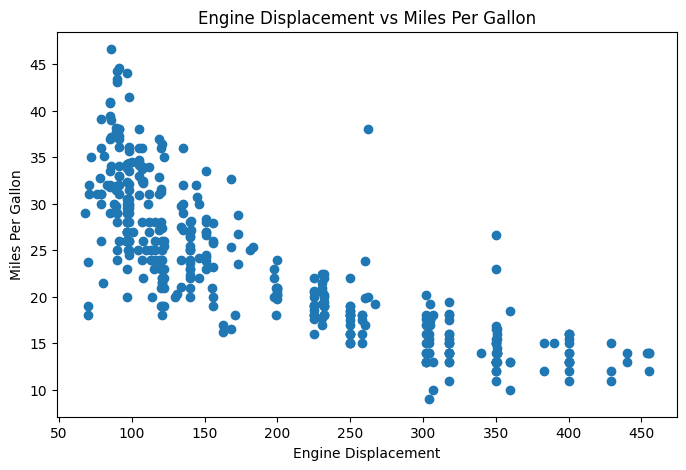

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(x,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon")

plt.title("Engine Displacement vs Miles Per Gallon")

plt.show()

##Linear Regression

In [21]:
#model creation
linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

#prediction
linear_pred = linear_model.predict(x_test)

#evaluation
linear_mse = mean_squared_error(y_test, linear_pred)

linear_r2 = r2_score(y_test, linear_pred)

print(f"Mean Squared Error (MSE): {mse_linear}")
print(f"R² Score: {r2_linear}")

Mean Squared Error (MSE): 18.102543998358946
R² Score: 0.6633114869465596


##Polynomial Regression


In [29]:
results = []

for degree in [2, 3, 4]:

    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([degree, mse, r2])

#print results
results_df = pd.DataFrame(
    results,
    columns=['Degree','MSE','R2']
)

print(results_df)

   Degree        MSE        R2
0       2  15.107354  0.719019
1       3  14.943632  0.722064
2       4  14.961487  0.721732


##Compare with Linear Regression


In [30]:
comparison = pd.DataFrame({

    "Model":[
        "Linear",
        "Polynomial Degree 2",
        "Polynomial Degree 3",
        "Polynomial Degree 4"
    ],

    "MSE":[
        linear_mse,
        results[0][1],
        results[1][1],
        results[2][1]
    ],

    "R2":[
        linear_r2,
        results[0][2],
        results[1][2],
        results[2][2]
    ]
})

print(comparison)

                 Model        MSE        R2
0               Linear  18.102544  0.663311
1  Polynomial Degree 2  15.107354  0.719019
2  Polynomial Degree 3  14.943632  0.722064
3  Polynomial Degree 4  14.961487  0.721732


##Visualization


Scatter Graph


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


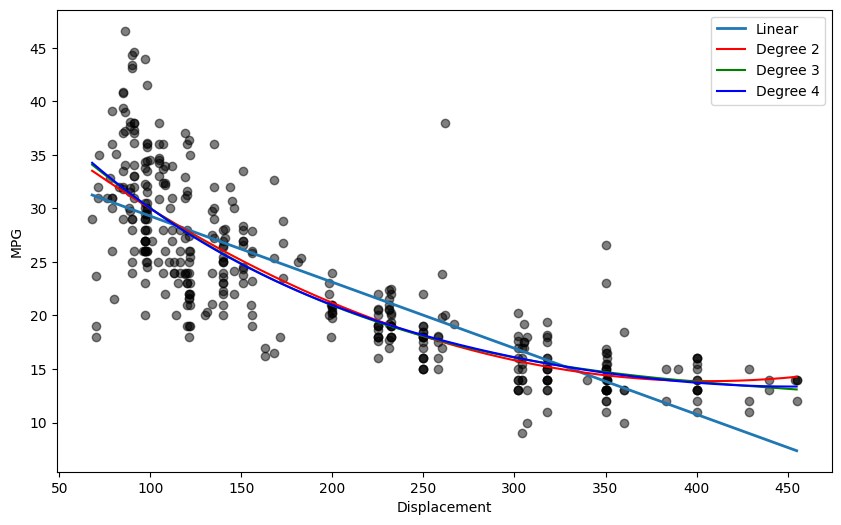

In [39]:
x_range = np.linspace(
    x.min(),
    x.max(),
    300
).reshape(-1,1)

#scatter graph
plt.figure(figsize=(10,6))
print("Scatter Graph")
plt.scatter(x, y, color='black', alpha=0.5)

#linear graph

plt.plot(
    x_range,
    linear_model.predict(x_range),
    label='Linear',
    linewidth=2
)

#polyomial

colors = ['red','green','blue']

for degree,color in zip([2,3,4],colors):

    model = Pipeline([
        ('poly', PolynomialFeatures(degree)),
        ('linear', LinearRegression())
    ])

    model.fit(x,y)

    plt.plot(
        x_range,
        model.predict(x_range),
        color=color,
        label=f'Degree {degree}'
    )

plt.xlabel("Displacement")

plt.ylabel("MPG")

plt.legend()

plt.show()

##Conclusion
Linear Regression assumes a straight-line relationship between displacement and MPG.

Polynomial Regression captures the nonlinear relationship by adding higher-degree terms.

Among the tested models, the polynomial model with the highest R² and lowest MSE provides the best fit.

However, increasing the degree too much may lead to overfitting.